# Local expmnation of noun phrases of VLM
### Step 1: Generate the concept matix for noun phrases for (crop, concept pair)
### Step 2: Run an inference with an image or without an image. get all the embedding of the noun phrases
### Step 3: Select one embedding corresponds to the noun phrase of step 2 
### Step 4: Project the embedding to the concept matrix and get the corresponding images
### Step 5: Select random images from the concept matrix and ask VLM to describe the images and get the noun phrases from them.


In [ ]:
# Create crops of image
# Rnadom patch 
import os
import random
from PIL import Image
from pathlib import Path

def create_random_patches(image_path, patch_size, output_dir, P):
    img = Image.open(image_path)
    img_name = Path(image_path).stem
    width, height = img.size

    if width < patch_size or height < patch_size:
        print(f"Skipping {image_path}: smaller than patch size.")
        return

    os.makedirs(output_dir, exist_ok=True)

    for i in range(P):
        left = random.randint(0, width - patch_size)
        top = random.randint(0, height - patch_size)
        right = left + patch_size
        bottom = top + patch_size
        patch = img.crop((left, top, right, bottom))
        patch_filename = f"{img_name}_patch_{i}.png"
        patch.save(os.path.join(output_dir, patch_filename))

def process_folder_structure(root_input, root_output, patch_size=128, P=10):
    for subdir, _, files in os.walk(root_input):
        rel_path = os.path.relpath(subdir, root_input)
        output_subdir = os.path.join(root_output, rel_path)
        os.makedirs(output_subdir, exist_ok=True)

        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(subdir, file)
                create_random_patches(image_path, patch_size, output_subdir, P)

# Example usage
#input_root = '/mnt/abka03/xlvlm_data/coco_50_samples/train'
#output_root = '/mnt/abka03/xlvlm_data/coco_crops/train'
process_folder_structure(input_root, output_root, patch_size=100, P=20)


KeyboardInterrupt: 

## Generate Concept matrix

In [ ]:
# After creating the crops udate the embdeing_extraction.sh file for requred concept names.
#  run ./embdeing_extraction.sh in command line




In [ ]:
# Create sudo CAV for each concept file
# ./sudo_cav_projection.sh  

In [ ]:
# Read all .pth file
# Combibne all concepts and discard negative cocnecpt
# Sudo CAV
import os
import torch

# Replace with your directory path
directory = '/mnt/abka03/concept_extraction_result/MCoX/SNMF/noisy10/train/concept'

# List all .pth files in the directory
pth_files = [f for f in os.listdir(directory) if f.endswith('.pth')]

# Load each .pth file
new_decomose_data = {
    'concepts': [],
    'activations': [],
    'decomposition_method': [],
    'text_grounding': [],
    'image_grounding_paths': [],
    'analysis_model':[],
}
concepts = []
activations = []
decomposition_method = []
text_grounding = []
image_grounding_paths = []
models = []
for filename in pth_files:
    filepath = os.path.join(directory, filename)
    model_data = torch.load(filepath)
    image_grouning_path = model_data['image_grounding_paths']
    print("image_grouning_path", image_grouning_path)
    index_with_all_no  = max(
            range(len(image_grounding_path)),
        key=lambda i: sum(1 for item in image_grounding_path[i] if not item.startswith("No"))
    )
    print("index_with_all_no", index_with_all_no)
    
    concept = model_data['concepts'][index_with_all_no]
    #print(concept.shape)
    concepts.append(concept)
    activation = model_data['activations'][:,index_with_all_no]
    print("activation shape",  model_data['activations'].shape)
    activations.append(activation)
    decomposition_method = model_data['decomposition_method']
    text_grounding.append(model_data['text_grounding'][index_with_all_no])
    new_decomose_data['concepts'].append(concept)
    image_grounding_path = model_data['image_grounding_paths'][index_with_all_no]
    image_grounding_paths.append(image_grounding_path)
    analysis_model = model_data['analysis_model']
    models.append(analysis_model)
concepts = torch.stack(concepts, dim=0)
print("concepts shape", concepts.shape)
activations = torch.stack(activations, dim=1)
print("Activation shape", activations.shape)
new_decomose_data['activations'] = activations
new_decomose_data['concepts'] = concepts
new_decomose_data['decomposition_method'] = decomposition_method
new_decomose_data['text_grounding'] = text_grounding
new_decomose_data['image_grounding_paths'] = image_grounding_paths
new_decomose_data['analysis_model'] = models
torch.save(new_decomose_data, "/mnt/abka03/concept_extraction_result/MCoX/SNMF/noisy10/train/concept/combined_concept.pth")


image_grouning_path [['No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0031.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0026.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0019.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0024.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0034.jpg'], ['No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0036.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0016.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0008.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0028.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/garbage_truck/train_train_0041.jpg']]
index_with_all_no 0
activation shape torch.Size([50, 2])
image_grouning_path [['No@/mnt/abka03/xlvlm_data/noise_image/train/french_horn/hot_dog_train_0019.

image_grouning_path [['No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0027.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0046.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0022.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0029.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0014.jpg'], ['No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0043.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0032.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0001.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0018.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/fish/bus_train_0039.jpg']]
index_with_all_no 0
activation shape torch.Size([50, 2])
image_grouning_path [['No@/mnt/abka03/xlvlm_data/noise_image/train/gas_station/cat_train_0015.jpg', 'No@/mnt/abka03/xlvlm_data/noise_image/train/gas_station/cat_train_0033.jpg', 'No@/mnt/abka03/xlvlm_data/noi

In [ ]:

import torch
import numpy as np

# Load the .pth file
pth_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/imagenet1000/train/concept/combined_concept_l2zca.pth"
data = torch.load(pth_path)

# Extract 'concepts'
concepts = data['concepts']  # assume it's a numpy array or tensor

# Convert to numpy if it's a tensor
if isinstance(concepts, torch.Tensor):
    concepts_np = concepts.cpu().numpy()
else:
    concepts_np = concepts

# Apply UMAP with same number of components (no dimensionality reduction)
n_components = concepts_np.shape[1]


from sklearn.preprocessing import normalize

concepts_normalized = normalize(concepts_np, norm='l2')

# Replace original 'concepts' with reshaped version
data['concepts'] = torch.tensor(concepts_normalized , dtype=torch.float32)

# Save to new file
new_pth_path = "/mnt/abka03/concept_extraction_result/coco_sentence/CAV/combined_concept_decomposition_l2.pth"
torch.save(data, new_pth_path)

print(f"L2-applied concept embeddings saved to {new_pth_path}")


In [ ]:
# FInd the CAV from sudo CAV

import numpy as np

# ZCA Whitening function
def zca_whiten(X):
    # Center the data by subtracting the mean
    X_centered = X - np.mean(X, axis=0)
    
    # Compute the covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)
    
    # Eigenvalue decomposition
    U, S, _ = np.linalg.svd(cov_matrix)  # U is eigenvectors, S are eigenvalues
    
    # Compute the whitening matrix
    epsilon = 1e-5  # A small value to avoid division by zero
    whitening_matrix = np.dot(U, np.dot(np.diag(1.0 / np.sqrt(S + epsilon)), U.T))
    
    # Apply whitening
    X_whitened = np.dot(X_centered, whitening_matrix)
    
    return X_whitened
import torch
import numpy as np

# Load the .pth file
pth_path = "/mnt/abka03/concept_extraction_result/coco_sentence/CAV/combined_concept_decomposition_l2.pth"
data = torch.load(pth_path)

# Extract 'concepts'
concepts = data['concepts']  # assume it's a numpy array or tensor

# Convert to numpy if it's a tensor
if isinstance(concepts, torch.Tensor):
    concepts_np = concepts.cpu().numpy()
else:
    concepts_np = concepts

# Assuming concepts_np is your original data (numpy array)
concepts_whitened = zca_whiten(concepts_np)

# If you want to replace the original concepts with the whitened version
data['concepts'] = torch.tensor(concepts_whitened,  dtype=torch.float32)

# Save the new dictionary with ZCA-whitened concepts
new_pth_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/coco62concepts/train/concept/combined_concept_l2zca.pth"
torch.save(data, new_pth_path)

print(f"ZCA-whitened concept embeddings saved to {new_pth_path}")


## Visualize concept set

In [3]:
# Import libraries to visualize the results
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import matplotlib
import pydicom
from PIL import Image
import numpy as np
import os
import torch
print("Matplotlib version for info:", matplotlib.__version__)

Matplotlib version for info: 3.9.4


dict_keys(['concepts', 'activations', 'decomposition_method', 'text_grounding', 'image_grounding_paths', 'analysis_model'])


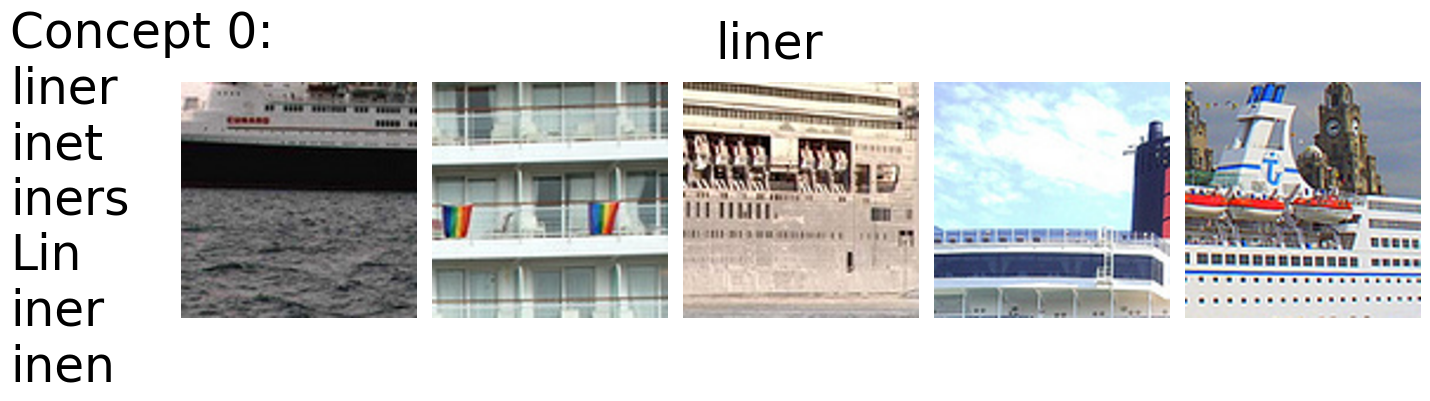

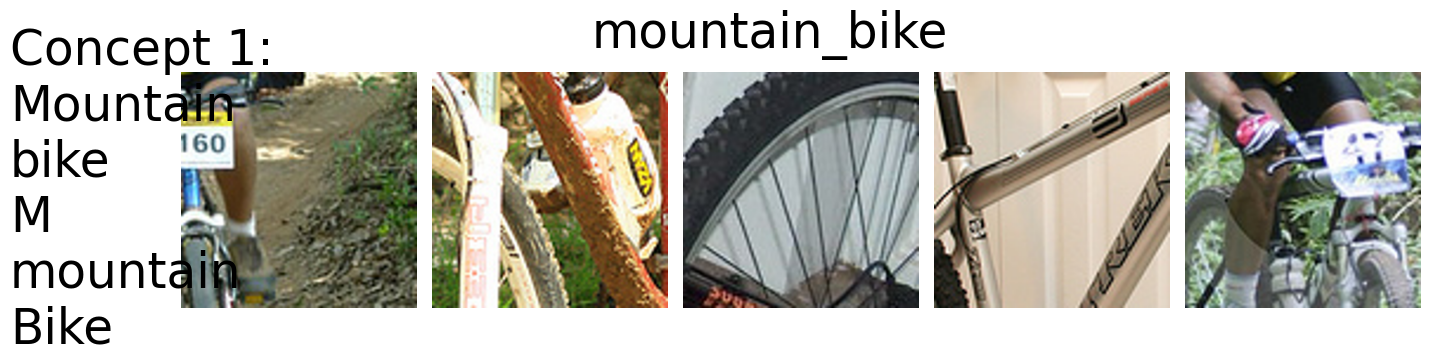

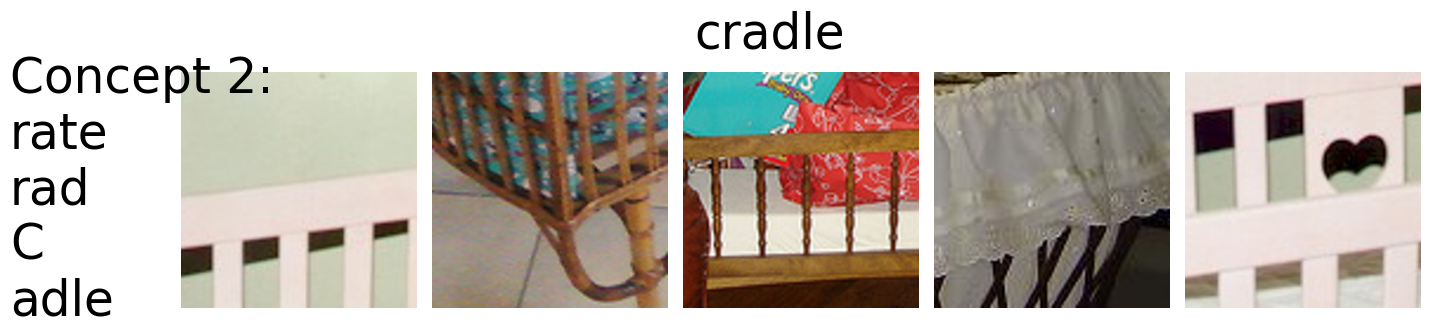

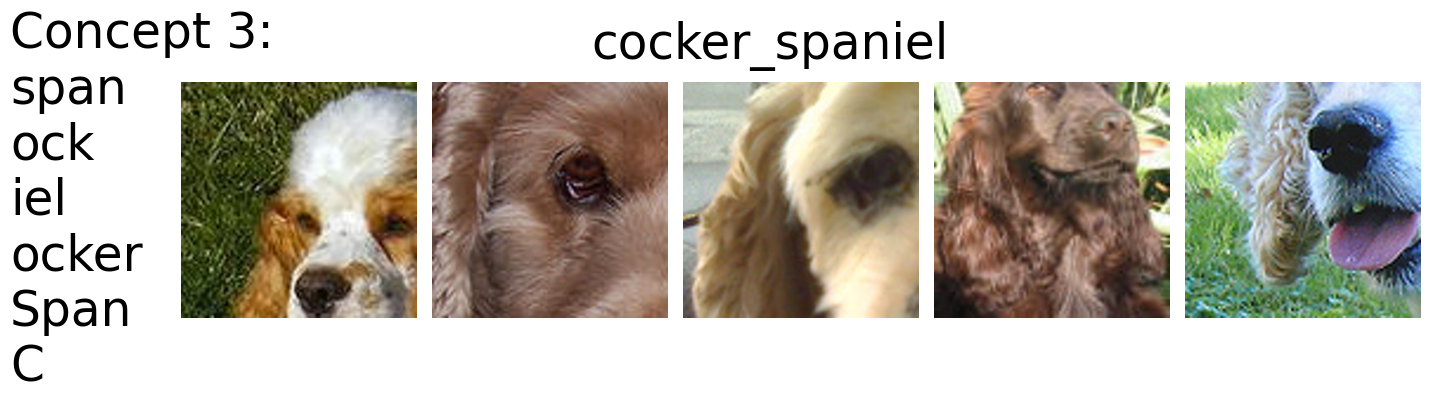

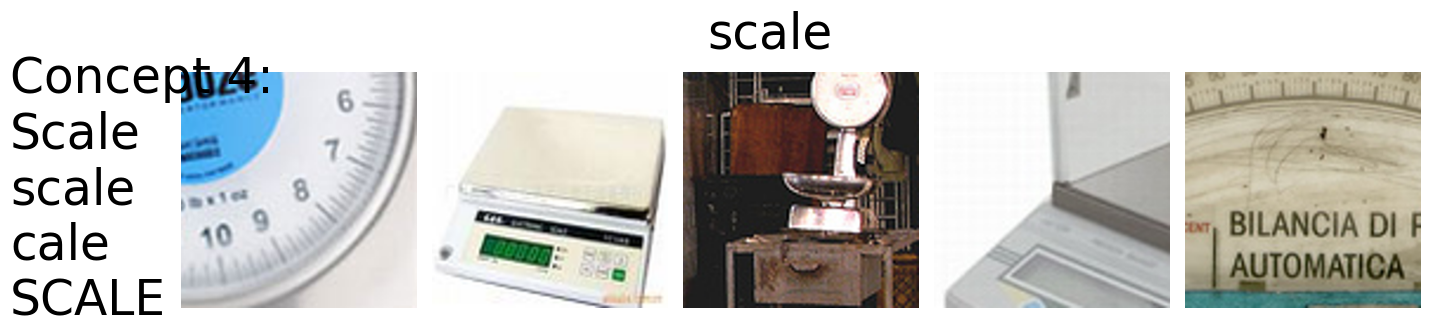

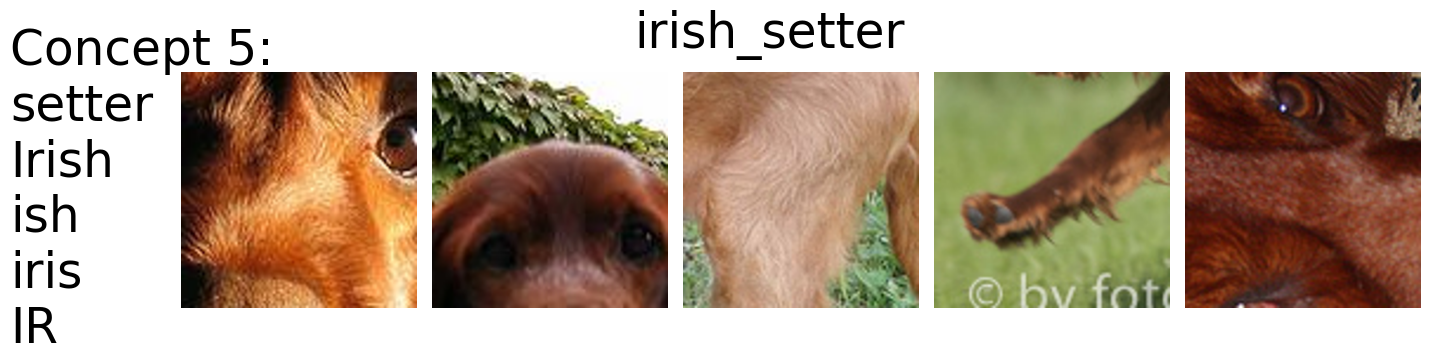

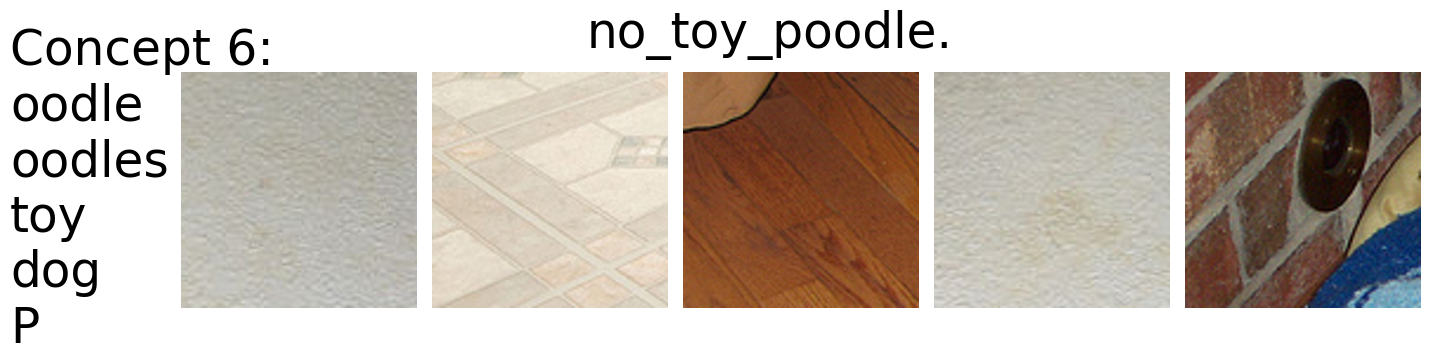

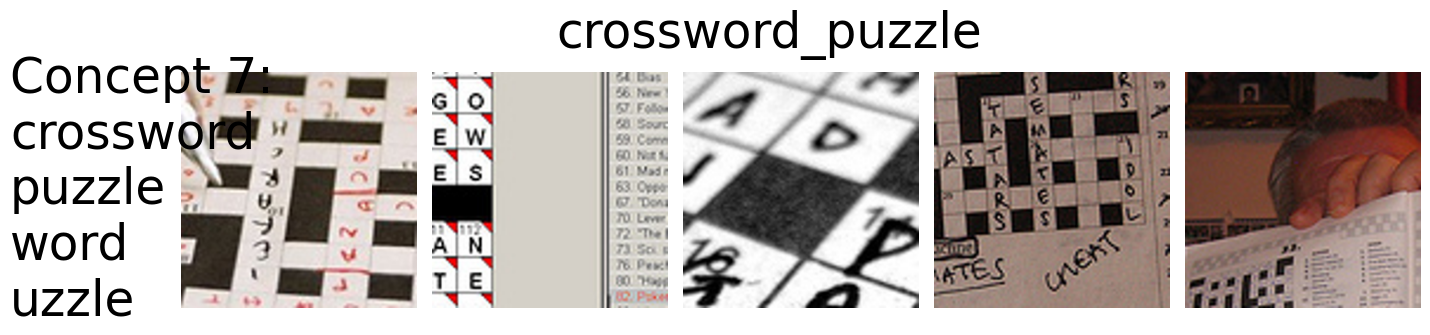

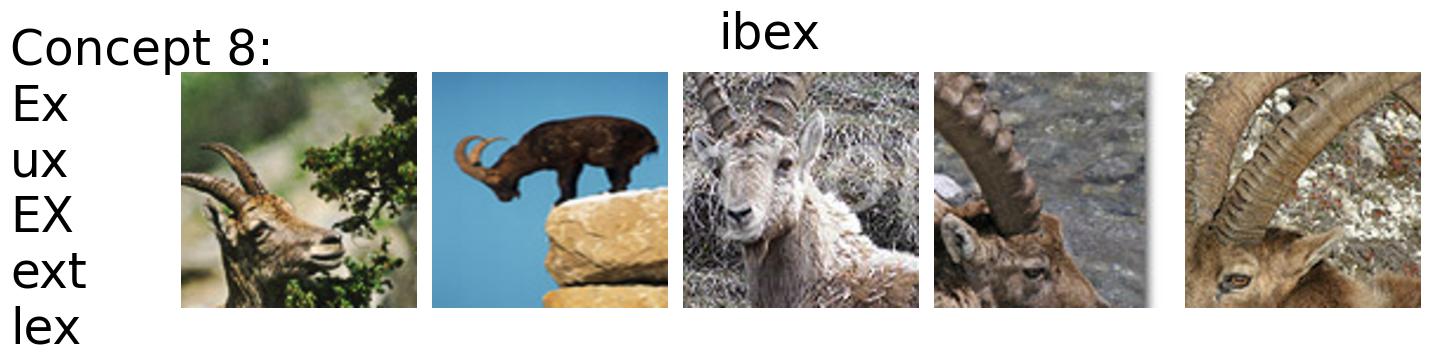

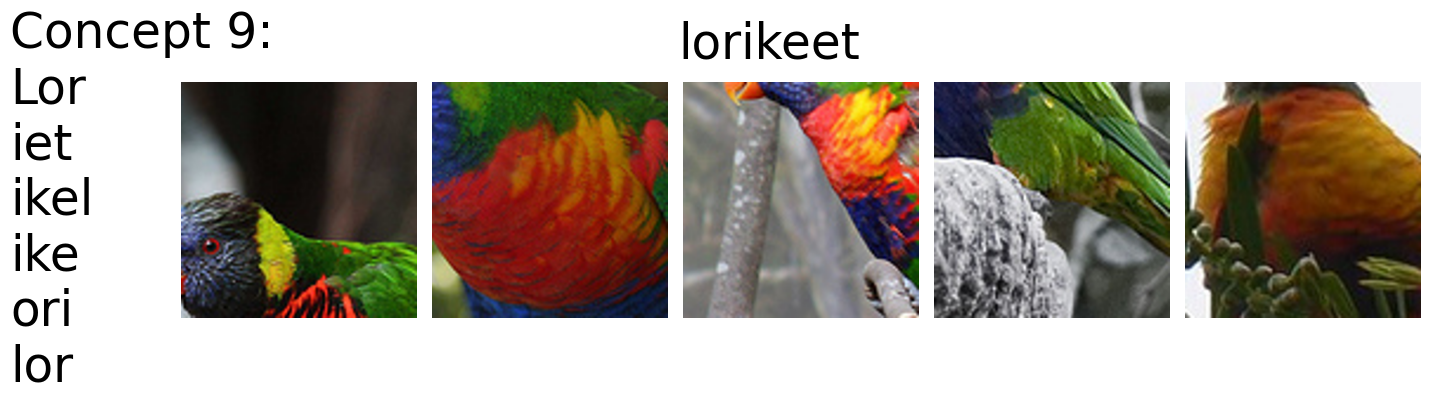

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import pydicom

num_concepts = 10# Number of concepts to visualize
results_filename = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/imagenet1000/train/concept/combined_concept_l2zca.pth" # Path to the results file for concept embeddings
#results_filename = "/mnt/abka03/concept_extraction/CAV/concept_grounding_zca.pth"# Path to the results file for concept embeddings
concept_data = torch.load(results_filename)
print(concept_data.keys())
concept_image = concept_data["image_grounding_paths"]
concept_text = concept_data['text_grounding']

def load_image(file_path):
    ext = os.path.splitext(file_path)[-1].lower()
    if ext == ".dcm":
        dicom_data = pydicom.dcmread(file_path)
        image = dicom_data.pixel_array
        return image
    elif ext in [".jpeg", ".jpg", ".png"]:
        image = Image.open(file_path)
        return np.array(image)
    else:
        raise ValueError(f"Unsupported file format: {ext}")
def visualize_grounding(concept_idx, concept_text, image_paths):
    concept_names = concept_text[concept_idx]
    paths = image_paths[concept_idx]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept.lower())
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    unique_concepts = sorted(set(concept_list))

    # Increase figure width to add padding on the left
    fig = plt.figure(figsize=(num_imgs * 2.5 + 3, 4))  # +3 adds space for left padding

    # Title row: unique concepts
    fig.suptitle(', '.join(unique_concepts), fontsize=35, x=0.5, y=0.95)

    # Adjust left start position of image axes to make room for label text
    gap = 0.01  # small gap between images
    image_width = (0.8 - (num_imgs - 1) * gap) / num_imgs  # distribute remaining space

    for i in range(num_imgs):
        left = 0.12 + i * (image_width + gap)  # start position shifts with gap
        ax = fig.add_axes([left, 0.1, image_width, 0.8])
        ax.imshow(images[i])
        ax.axis('off')

    # Add concept ID and names vertically on the left
    label_text = f"Concept {concept_idx}:\n" + "\n".join(concept_names)
    fig.text(0.01, 0.5, label_text, va='center', ha='left', fontsize=35)

    plt.show()


# Visualize all concepts
for k in range(num_concepts):
    visualize_grounding(k, concept_text, concept_image)


## Local Explantion

In [10]:
# Get the feature for one image 
concept_example = 'fire hydrant' #{concept_example.replace(' ', '_')}
image = f"/mnt/abka03/xlvlm_data/coco_50_samples/val/fire_hydrant/COCO_val2014_000000489346.jpg"
#image = "/mnt/abka03/Projects/xl-vlms/playground/dataset/recipe-desktop-merkts-cheesy-hot-dawg.jpg"
!cd ../ && python src/save_features.py \
    --model_name "Qwen/Qwen2-VL-7B-Instruct" \
    --dataset_name "image" \
    --data_dir $image \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.norm" \
    --save_dir "/mnt/abka03/xl-vlms" \
    --save_filename "qwen2_image_coco_hidden_states" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"

[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-05-23 23:14:57,643 - INFO - Loading model: Qwen/Qwen2-VL-7B-Instruct
2025-05-23 23:14:57,643 - INFO - Arguments:
2025-05-23 23:14:57,643 - INFO - seed: 0
2025-05-23 23:14:57,643 - INFO - model_name_or_path: Qwen/Qwen2-VL-7B-Instruct
2025-05-23 23:14:57,643 - INFO - processor_name: None
2025-05-23 23:14:57,643 - INFO - local_files_only: False
2025-05-23 23:14:57,643 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-05-23 23:14:57,643 - INFO - prompt_template: llava
2025-05-23 23:14:57,643 - INFO - prompt: Describe the image in detail.
2025-05-23 23:14:57,643 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_50_samples/val/fire_hydrant/COCO_val2014_000000489346.jpg
2025-05-23 23:14:57,643 - INFO - annotation_file: annotations.json
2025-05-23 23:14:57,643 - INFO - questions_file: annotations.json
2025-05-23 23:14:57,643 - INFO - answer_type_to_answer: None
2025-05-23 23

In [9]:
# Project the image to the concept and explain 

import sys

script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)

from analysis.feature_decomposition import get_feature_matrix
module_name = "model.norm"
token_idx = None
output = torch.load("/mnt/abka03/xl-vlms/features/save_hidden_states_noun_phrase_qwen2_image_coco_hidden_states.pth")


absolute_features = output["hidden_states"]

feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )



phrase_and_text_prediction = output["model_predictions"]
phrases = [out[0].split("@")[0] for out in phrase_and_text_prediction]
print("Model predcition is: ", output["model_predictions"][0][0].split("@")[0])
print("Phrases are: ", phrases)

test_image_file_name = output["image"]



IndexError: list index out of range

In [ ]:
# project the image feature to concepts
#import analysis.feature_decomposition as analysis_decomposition
analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]

feat_matrix = feat_matrix.float()
projections = feat_matrix @ concept_data["concepts"].T
print(projections.shape)

import numpy as np

def find_top_n_powerful_projection(data, n):
    """
    Finds the top n elements for each row along with their indices.

    Parameters:
    - data: List of lists or 2D numpy array.
    - n: Number of top values to find.

    Returns:
    - A list of lists, where each sublist contains tuples of (index, value) 
      representing the top n elements and their indices for the corresponding row.
    """
    # Ensure the input is a numpy array
    data = np.array(data)
    
    # Get the top n indices and values for each row
    top_n_indices = [np.argsort(row)[-n:][::-1] for row in data]
    top_n_pairs = [[(idx, row[idx]) for idx in idxs] for row, idxs in zip(data, top_n_indices)]
    
    return top_n_pairs

n = 15 #mumber of concept to discover 
top_powerful_indexes = find_top_n_powerful_projection(projections, n)

def remap_prjection_image_text(top_powerful_indexes, test_image_path, image_concept_path, phrase_concept_path, text_concept_path):
    if len(top_powerful_indexes) != len(test_image_path):
        raise ValueError("The projection list and image list of test data not have equal number.")
    
    print("Image concept path:",len(test_image_path))
    final_result = {}
    for each_image_path, concept_indexs in zip(test_image_path, top_powerful_indexes, ):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs], 'phrase_concept': [phrase_concept_path[i[0]] for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


image_grounding_paths = concept_data["image_grounding_paths"]
phrase_grounding_paths = concept_data['image_grounding_paths']
text_grounding_paths = concept_data["text_grounding"]
test_data_remapped = remap_prjection_image_text(top_powerful_indexes, test_image_file_name, image_grounding_paths, phrase_grounding_paths, text_grounding_paths)



def load_image_as_rgb(filepath):
    """
    Load an image (DICOM, PNG, JPG) and return its RGB data as a NumPy array.

    Args:
        filepath (str): Path to the image file.

    Returns:
        np.ndarray: RGB data as a NumPy array.
    """
    # Check file extension
    file_ext = filepath.split(".")[-1].lower()

    if file_ext in ["png", "jpg", "jpeg"]:
        # For PNG or JPG, use Pillow
        image = Image.open(filepath).convert("RGB")  # Ensure it's RGB
        return np.array(image).astype(np.uint8)

    elif file_ext == "dcm":
        # For DICOM, use pydicom
        dicom_file = pydicom.dcmread(filepath)

        # Apply modality LUT if necessary to get pixel values
        image_data = apply_modality_lut(dicom_file.pixel_array, dicom_file)

        # Normalize to 0-255 for RGB conversion (if necessary)
        if np.max(image_data) > 255:
            image_data = (image_data / np.max(image_data)) * 255.0

        # Convert grayscale to RGB (if it's single-channel)
        if len(image_data.shape) == 2:  # Grayscale image
            image_data = np.stack([image_data] * 3, axis=-1)  # Convert to RGB

        return image_data.astype(np.uint8)

    else:
        raise ValueError(f"Unsupported file format: {file_ext}")


import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualize_local_explantion(concept_idx, concept_text, image_paths):
    concept_names_scores = concept_text[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept.lower())
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    unique_concepts = sorted(set(concept_list))
    projection_score = concept_names_scores[1].item()

    # Increase figure height to fit projection score bar
    fig = plt.figure(figsize=(num_imgs * 2.5 + 3, 5.5))  # Height increased

    # Title row: unique concepts
    fig.suptitle(', '.join(unique_concepts), fontsize=35, x=0.5, y=0.95)

    # Image layout
    gap = 0.01
    image_width = (0.8 - (num_imgs - 1) * gap) / num_imgs

    for i in range(num_imgs):
        left = 0.12 + i * (image_width + gap)
        ax = fig.add_axes([left, 0.25, image_width, 0.6])  # Adjusted y-position
        ax.imshow(images[i])
        ax.axis('off')

    # Add concept ID and names on the left
    label_text = f"Concept {concept_idx}:\n" + "\n".join(concept_names_scores[0]) 
    fig.text(0.01, 0.5, label_text, va='center', ha='left', fontsize=35)

    # Add projection score bar (horizontal, centered on 0)
    ax_bar = fig.add_axes([0.12, 0.1, 0.75, 0.05])  # [left, bottom, width, height]
    ax_bar.barh([0], [projection_score], height=0.5, color='red')
    ax_bar.set_xlim([-500, 500])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([-500, 0, 500])
    ax_bar.set_xticklabels(['-500', '0', '500'], fontsize=20)
    ax_bar.axvline(0, color='black', linewidth=1)  # center line
    ax_bar.set_title('Projection Score', fontsize=34, loc='left')

    # Add value to the right of the bar
    fig.text(0.88, 0.11, f"{round(projection_score)}", va='center', ha='left', fontsize=34)

    plt.show()


    

def local_explantion(a_test_image,test_data_remapped):
    
# Provide the file path to the image
    image_path = a_test_image.split("@")[1]

    # Read and display the image
    img = load_image_as_rgb(image_path)
    fig = plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap="gray")
    plt.axis('off')  # Optional: Turn off the axis
    plt.show()
    key = a_test_image
    text_concepts = test_data_remapped[key]
    for i in range(n):
         visualize_local_explantion(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )


In [ ]:
test_image = test_image_file_name
print("All phrases:",len( test_image))


In [ ]:
#explain one noun phrase
phrase_number = 11
a_test_phrase_with_image = test_image[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion(a_test_phrase_with_image, test_data_remapped)

## Explain text with images in vlm.
### We have the image concepts

### First get the embedding for a text 



In [ ]:
# Get the feature for one image 

!cd ../ && python src/save_features.py \
    --model_name "Qwen/Qwen2-VL-7B-Instruct" \
    --dataset_name "text" \
    --data_dir "orange" \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.norm" \
    --save_dir "/mnt/abka03/xl-vlms" \
    --save_filename "qwen2_text_hidden_states" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"

In [ ]:
text_feature_path = "/mnt/abka03/xl-vlms/features/save_hidden_states_noun_phrase_qwen2_text_hidden_states.pth"
output = torch.load(text_feature_path)
#print(output)
absolute_features = output["hidden_states"]
print(output["model_predictions"])



In [ ]:
# Project the text in to the concept and explain
from analysis.feature_decomposition import get_feature_matrix
script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)


module_name = 'model.norm'
token_idx = None
output = torch.load(text_feature_path)
absolute_features = output["hidden_states"]
feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )


analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]
feat_matrix = feat_matrix.float()
print(feat_matrix.type(), concept_data["concepts"].T.type())
projections = feat_matrix @ concept_data["concepts"].T

print(projections.shape)
top_powerful_indexes = find_top_n_powerful_projection(projections, n)
test_text = output['model_predictions']
def remap_prjection_text(top_powerful_indexes, test_text, image_concept_path,  text_concept_path):
    if len(top_powerful_indexes) != len(test_text):
        raise ValueError("The projection list and image list of test data not have equal number.")
    
    print("Test cocept text:",len(test_text))
    final_result = {}
    for each_image_path, concept_indexs in zip(test_text, top_powerful_indexes):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


text_grounding_paths = concept_data["text_grounding"]
test_data_remapped_text = remap_prjection_text(top_powerful_indexes, test_text , image_grounding_paths, text_grounding_paths)




def  visualize_grounding_text(concept_idx, concept_text, image_paths):
    concept_names_scores = concept_text[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept.lower())
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    unique_concepts = sorted(set(concept_list))
    projection_score = concept_names_scores[1].item()

    # Increase figure height to fit projection score bar
    fig = plt.figure(figsize=(num_imgs * 2.5 + 3, 5.5))  # Height increased

    # Title row: unique concepts
    fig.suptitle(', '.join(unique_concepts), fontsize=35, x=0.5, y=0.95)

    # Image layout
    gap = 0.01
    image_width = (0.8 - (num_imgs - 1) * gap) / num_imgs

    for i in range(num_imgs):
        left = 0.12 + i * (image_width + gap)
        ax = fig.add_axes([left, 0.25, image_width, 0.6])  # Adjusted y-position
        ax.imshow(images[i])
        ax.axis('off')

    # Add concept ID and names on the left
    label_text = f"Concept {concept_idx}\n" + "\n".join(concept_names_scores[0]) 
    fig.text(0.01, 0.5, label_text, va='center', ha='left', fontsize=35)

    # Add projection score bar (horizontal, centered on 0)
    ax_bar = fig.add_axes([0.12, 0.1, 0.75, 0.05])  # [left, bottom, width, height]
    ax_bar.barh([0], [projection_score], height=0.5, color='red')
    ax_bar.set_xlim([-500, 500])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([-500, 0, 500])
    ax_bar.set_xticklabels(['-500', '0', '500'], fontsize=20)
    ax_bar.axvline(0, color='black', linewidth=1)  # center line
    ax_bar.set_title('Projection Score', fontsize=34, loc='left')

    # Add value to the right of the bar
    fig.text(0.88, 0.11, f"{round(projection_score)}", va='center', ha='left', fontsize=34)

    plt.show()

n=15
def local_explantion_text(a_test_image,test_data_remapped):
    
    text_concepts = test_data_remapped[a_test_image]
    for i in range(n):
         visualize_grounding_text(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )
test_text = output['model_predictions']
print("All text:", test_text)
#explain one noun phrase
phrase_number = 0
a_test_phrase_with_image = test_text[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion_text(a_test_phrase_with_image, test_data_remapped_text )

